Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 75s 93ms/step - accuracy: 0.4090 - loss: 1.6024 - val_accuracy: 0.5277 - val_loss: 1.3090
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 71s 91ms/step - accuracy: 0.5634 - loss: 1.2266 - val_accuracy: 0.6162 - val_loss: 1.0925
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 81s 90ms/step - accuracy: 0.6213 - loss: 1.0771 - val_accuracy: 0.6470 - val_loss: 1.0100
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 82s 90ms/step - accuracy: 0.6585 - loss: 0.9737 - val_accuracy: 0.6754 - val_loss: 0.9218
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 81s 89ms/step - accuracy: 0.6893 - loss: 0.9011 - val_accuracy: 0.6945 - val_loss: 0.8748
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.6945 - loss: 0.8748
Test Accuracy: 0.6945000290870667


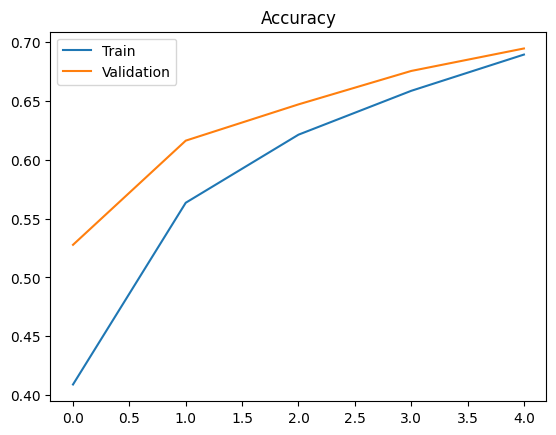

In [3]:
# Import Libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np

# Load dataset
(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0


# -----------------------------
# Simple Fast CNN Model
# -----------------------------

model = keras.Sequential([

    layers.Conv2D(32,(3,3),activation='relu',input_shape=(32,32,3)),
    layers.MaxPooling2D(),

    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128,(3,3),activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128,activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(10,activation='softmax')
])


# Compile (thoda fast learning ke liye LR increase kiya)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0015),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


# -----------------------------
# Train (ONLY 5 epochs)
# -----------------------------
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_data=(X_test, y_test)
)


# Evaluate
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_acc)


# -----------------------------
# Graph
# -----------------------------
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.legend()
plt.title("Accuracy")
plt.show()